In [46]:
import pandas as pd

In [47]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [48]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [49]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [50]:
print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


In [51]:
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

0
0


In [52]:
print(sentiment.isnull().sum())
print("-------------------")
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
-------------------
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [53]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [54]:
trades = trades.rename(columns={
    'Account': 'account',
    'Closed PnL': 'pnl',
    'Size USD': 'size_usd',
    'Side': 'side'
})

In [55]:
df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [56]:
print(df['date'].min(), df['date'].max())
print(sentiment['date'].min(), sentiment['date'].max())

2023-05-01 2025-05-01
2018-02-01 2025-05-02


In [57]:
df['win'] = df['pnl'] > 0

In [58]:
df.groupby('classification')['pnl'].mean()
df.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

In [59]:
pd.crosstab(df['classification'], df['side'], normalize='index')
df.groupby('classification')['size_usd'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64

In [60]:
print(trades['date'].min(), trades['date'].max())
print(sentiment['date'].min(), sentiment['date'].max())

2023-05-01 2025-05-01
2018-02-01 2025-05-02


In [61]:
sentiment = sentiment[
    (sentiment['date'] >= trades['date'].min()) &
    (sentiment['date'] <= trades['date'].max())
]

In [62]:
df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [63]:
print("Missing sentiment:", df['classification'].isnull().sum())

Missing sentiment: 6


In [64]:
df = df.dropna(subset=['classification'])

In [65]:
df['win'] = df['pnl'] > 0

In [66]:
pnl_by_sentiment = df.groupby('classification')['pnl'].mean()
winrate_by_sentiment = df.groupby('classification')['win'].mean()

print(pnl_by_sentiment)
print(winrate_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: pnl, dtype: float64
classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


In [67]:
df.groupby('classification').size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [68]:
df.groupby('classification')['size_usd'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64

In [69]:
pd.crosstab(df['classification'], df['side'], normalize='index')

side,BUY,SELL
classification,,
Extreme Fear,0.510981,0.489019
Extreme Greed,0.448590,0.551410
Fear,0.489513,0.510487
Greed,0.488559,0.511441
Neutral,0.503343,0.496657


In [70]:
threshold = df['size_usd'].median()

df['size_group'] = df['size_usd'].apply(
    lambda x: 'High' if x > threshold else 'Low'
)

In [71]:
trade_counts = df['account'].value_counts()
median_trades = trade_counts.median()

df['freq_group'] = df['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > median_trades else 'Infrequent'
)

In [72]:
total_pnl = df.groupby('account')['pnl'].sum()

df['trader_type'] = df['account'].apply(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

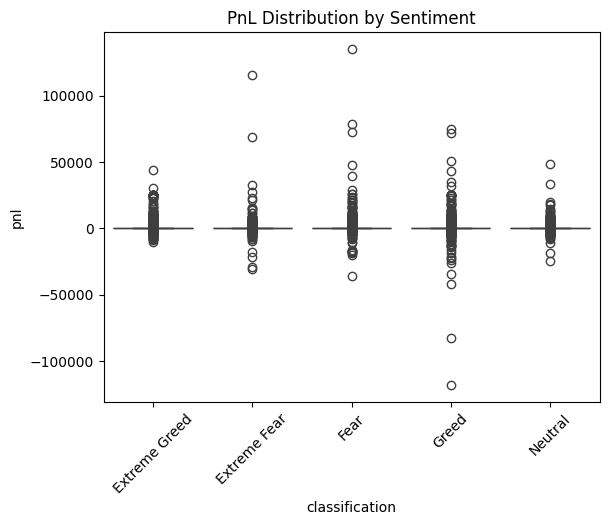

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='pnl', data=df)
plt.xticks(rotation=45)
plt.title("PnL Distribution by Sentiment")
plt.show()

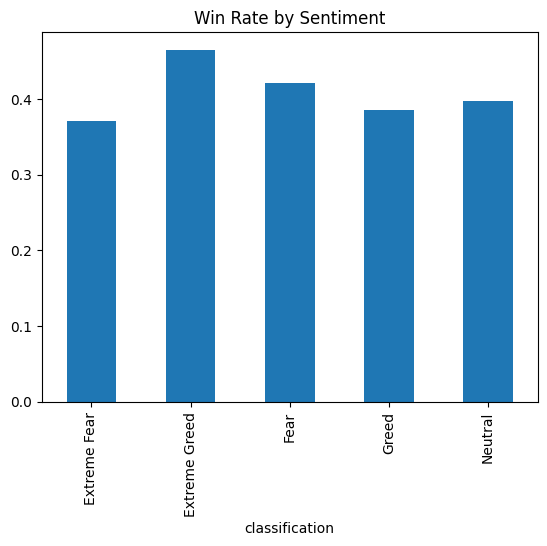

In [74]:
winrate_by_sentiment.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.show()

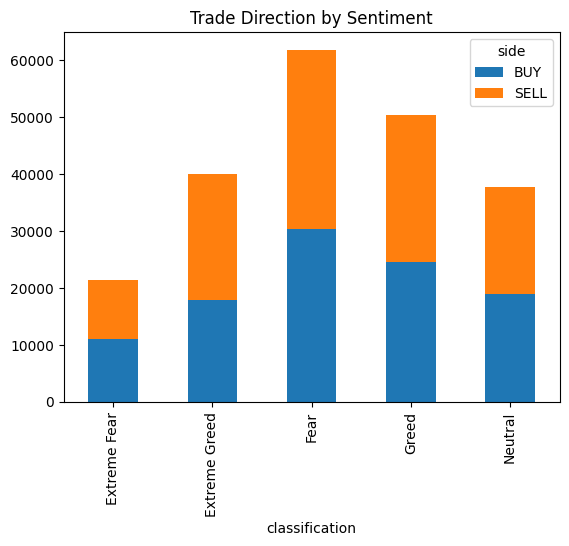

In [75]:
pd.crosstab(df['classification'], df['side']).plot(kind='bar', stacked=True)
plt.title("Trade Direction by Sentiment")
plt.show()

In [76]:
print(pnl_by_sentiment)
print(winrate_by_sentiment)
print(pd.crosstab(df['classification'], df['side'], normalize='index'))
print(df.groupby('classification')['size_usd'].mean())

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: pnl, dtype: float64
classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64
side                 BUY      SELL
classification                    
Extreme Fear    0.510981  0.489019
Extreme Greed   0.448590  0.551410
Fear            0.489513  0.510487
Greed           0.488559  0.511441
Neutral         0.503343  0.496657
classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64
